In [1]:
import numpy as np
import itertools
import time
from sklearn.model_selection import KFold

In [2]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    return np.mean(np.abs(y_pred - y_true))

In [ ]:
def cv(X, y, method, parameters, loss_function = mean_absolute_error, nfolds = 10, nrepetitions = 5):
    param_names = list(parameters.keys())
    param_values = list(parameters.values())

    combinations = list(itertools.product(*param_values))
    total_jobs = len(combinations) * nrepetitions * nfolds
    completed = 0

    start_time = time.time()

    losses = []

    for combination in combinations:
        params = dict(zip(param_names, combination))

        fold_losses = []

        for repetition in range(nrepetitions):
            kf = KFold(n_splits=nfolds, shuffle=True, random_state=repetition)

            for train_idx, test_idx in kf.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                model = method(**params)
                model.fit(X_train, y_train)

                prediction = model.predict(X_test)

                loss = loss_function(y_test, prediction)
                fold_losses.append(loss)

                completed += 1

                elapsed_time = time.time() - start_time
                avg = elapsed_time / completed
                remaining = avg * (total_jobs - completed)

                print(
                    f"\rProgress: {completed}/{total_jobs} "
                    f"({100 * completed / total_jobs:.1f}%) "
                    f"Remaining: {remaining:.1f}s",
                    end=""
                )
        
        avg_loss = np.mean(fold_losses)
        losses.append((avg_loss, params))
    
    print()

    if len(combinations) == 1:
        best_loss, best_params = losses[0]
    else:
        best_loss, best_params = min(losses, key=lambda x: x[0])

    best_model = method(**best_params)
    best_model.fit(X, y)

    best_model.cvloss = best_loss

    return best_model

In [4]:
class krr:
    
    def __init__(
            self,
            kernel='linear',
            kernelparameter=None,
            regularization=1.0
    ):
        self.kernel = kernel
        self.kernelparameter = kernelparameter
        self.regularization = regularization

        self.alpha = None
        self.Xtrain = None

    def _kernel(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'polynomial':
            return (X1 @ X2.T + 1) ** self.kernelparameter
        elif self.kernel == 'gaussian':
            sigma = self.kernelparameter

            X1_sq = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
            X2_sq = np.sum(X2 ** 2, axis=1).reshape(1, -1)

            dist = X1_sq + X2_sq - 2 * (X1 @ X2.T)
            return np.exp(-dist / (2 * sigma ** 2))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
            
    def fit(self, Xtrain, ytrain):
        self.Xtrain = Xtrain
        
        if self.regularization == 0:
            mean = np.mean(np.linalg.eigvalsh(self._kernel(Xtrain, Xtrain)))

            candidates = mean * np.logspace(-3, 3, 10)

            model = cv(
                Xtrain,
                ytrain, 
                krr, 
                {
                    'kernel': [self.kernel], 
                    'kernelparameter': [self.kernelparameter], 
                    'regularization': candidates
                }
            )

            self.regularization = model.regularization
        
        K = self._kernel(Xtrain, Xtrain)
        n = K.shape[0]

        self.alpha = np.linalg.solve(K + self.regularization * np.eye(n), ytrain)

        return self
    
    def predict(self, Xtest):
        Ktest = self._kernel(Xtest, self.Xtrain)
        return Ktest @ self.alpha

Progress: 1/4000 (0.0%) Remaining: 6.3s
Progress: 2/4000 (0.1%) Remaining: 5.2s
Progress: 3/4000 (0.1%) Remaining: 4.1s
Progress: 4/4000 (0.1%) Remaining: 3.5s
Progress: 5/4000 (0.1%) Remaining: 3.2s
Progress: 6/4000 (0.1%) Remaining: 3.0s
Progress: 7/4000 (0.2%) Remaining: 2.8s
Progress: 8/4000 (0.2%) Remaining: 2.7s
Progress: 9/4000 (0.2%) Remaining: 2.6s
Progress: 10/4000 (0.2%) Remaining: 2.6s
Progress: 11/4000 (0.3%) Remaining: 2.6s
Progress: 12/4000 (0.3%) Remaining: 2.6s
Progress: 13/4000 (0.3%) Remaining: 2.5s
Progress: 14/4000 (0.3%) Remaining: 2.5s
Progress: 15/4000 (0.4%) Remaining: 2.5s
Progress: 16/4000 (0.4%) Remaining: 2.5s
Progress: 17/4000 (0.4%) Remaining: 2.4s
Progress: 18/4000 (0.5%) Remaining: 2.4s
Progress: 19/4000 (0.5%) Remaining: 2.4s
Progress: 20/4000 (0.5%) Remaining: 2.4s
Progress: 21/4000 (0.5%) Remaining: 2.4s
Progress: 22/4000 (0.6%) Remaining: 2.4s
Progress: 23/4000 (0.6%) Remaining: 2.4s
Progress: 24/4000 (0.6%) Remaining: 2.4s
Progress: 25/4000 (0.6%) 

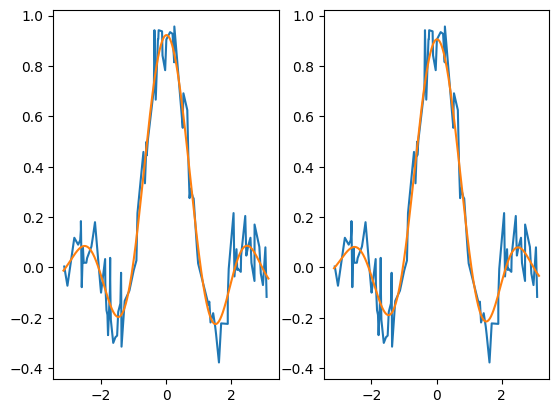

.

Progress: 1/500 (0.2%) Remaining: 0.6s
Progress: 2/500 (0.4%) Remaining: 0.5s
Progress: 3/500 (0.6%) Remaining: 0.4s
Progress: 4/500 (0.8%) Remaining: 0.4s
Progress: 5/500 (1.0%) Remaining: 0.3s
Progress: 6/500 (1.2%) Remaining: 0.3s
Progress: 7/500 (1.4%) Remaining: 0.3s
Progress: 8/500 (1.6%) Remaining: 0.3s
Progress: 9/500 (1.8%) Remaining: 0.3s
Progress: 10/500 (2.0%) Remaining: 0.3s
Progress: 11/500 (2.2%) Remaining: 0.3s
Progress: 12/500 (2.4%) Remaining: 0.3s
Progress: 13/500 (2.6%) Remaining: 0.3s
Progress: 14/500 (2.8%) Remaining: 0.3s
Progress: 15/500 (3.0%) Remaining: 0.3s
Progress: 16/500 (3.2%) Remaining: 0.3s
Progress: 17/500 (3.4%) Remaining: 0.3s
Progress: 18/500 (3.6%) Remaining: 0.3s
Progress: 19/500 (3.8%) Remaining: 0.2s
Progress: 20/500 (4.0%) Remaining: 0.2s
Progress: 21/500 (4.2%) Remaining: 0.2s
Progress: 22/500 (4.4%) Remaining: 0.2s
Progress: 23/500 (4.6%) Remaining: 0.2s
Progress: 24/500 (4.8%) Remaining: 0.2s
Progress: 25/500 (5.0%) Remaining: 0.2s
Progress:

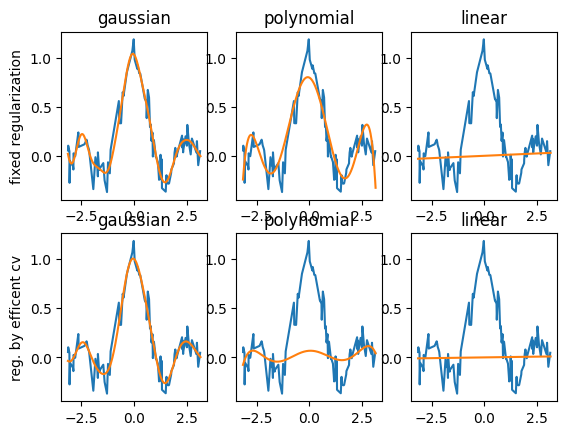

.
----------------------------------------------------------------------
Ran 2 tests in 55.153s

OK


In [5]:
import unittest

import numpy as np
import scipy.linalg as la
import pylab as pl

import sheet3 as imp

def squared_error_loss(y_true, y_pred):
    ''' returns the squared error loss
    '''
    assert(len(y_true) == len(y_pred))
    loss = np.mean( (y_true - y_pred)**2 )
    return loss

def noisysincfunction(N, noise):
    ''' noisysincfunction - generate data from the "noisy sinc function"
        % usage
        %     [X, Y] = noisysincfunction(N, noise)
        %
        % input
        %     N: number of data points
        %     noise: standard variation of the noise
        %
        % output
        %     X: (1, N)-matrix uniformly sampled in -2pi, pi
        %     Y: (1, N)-matrix equal to sinc(X) + noise
        %
        % description
        %     Generates N points from the noisy sinc function
        %
        %        X ~ uniformly in [-2pi, pi]
        %        Y = sinc(X) + eps, eps ~ Normal(0, noise.^2)
        %
        % author
        %     Mikio Braun
    '''
    X = np.sort(2 * np.pi * np.random.rand(1, N) ) - np.pi
    Y = np.sinc(X) + noise * np.random.randn(1, N)
    return X.reshape(-1, 1), Y.flatten()

class TestSheet3(unittest.TestCase):
    def test_krr(self):
        '''
            tests the class krr
        '''
        Xtr, Ytr = noisysincfunction(100, 0.1)
        Xte = np.arange( -np.pi, np.pi, 0.01 ).reshape(-1, 1)

        pl.figure()
        kernels = ['gaussian','polynomial','linear']
        titles = ['gaussian','polynomial','linear']
        params = [0.5,6,0]
        regularizations = [ 0.01,0.01,0.01]
        for i in range(3):
            for j in range(2):
                pl.subplot(2,3,1+i+3*j)
                if j==0:
                    krr = imp.krr(kernel=kernels[i],
                            kernelparameter=params[i],
                            regularization=regularizations[i])
                    krr.fit(Xtr,Ytr)
                if j==1:
                    krr = imp.krr(kernel=kernels[i],
                            kernelparameter=params[i],
                            regularization=0)
                    krr.fit(Xtr,Ytr)
                ypred = krr.predict(Xte)
                pl.plot(Xtr,Ytr)
                pl.plot(Xte,ypred)
                if j==0 and i == 0:
                    pl.ylabel('fixed regularization')
                if j==1 and i == 0:
                    pl.ylabel('reg. by efficent cv')
                pl.title( titles[i] )
        pl.show()

    def test_cv(self):
        Xtr, Ytr = noisysincfunction(100, 0.1)
        Xte = np.arange( -np.pi, np.pi, 0.01 ).reshape(-1, 1)

        pl.figure()
        pl.subplot(1,2,1)
        params = { 'kernel': ['gaussian'], 'kernelparameter': np.logspace(-4,4,20),
                      'regularization': np.logspace(-2,2,10) }
        cvkrr = imp.cv(Xtr, Ytr, imp.krr, params, loss_function=squared_error_loss,
                        nrepetitions=2)
        ypred = cvkrr.predict(Xte)
        print('Regularization range: 10**-4 .. 10**4')
        print('Gaussian kernel parameter: ', cvkrr.kernelparameter)
        print('Regularization paramter: ', cvkrr.regularization)

        pl.plot(Xtr,Ytr)
        pl.plot(Xte,ypred)

        pl.subplot(1,2,2)
        params = { 'kernel': ['gaussian'], 'kernelparameter': np.logspace(-2,2,10),
                      'regularization': [0]}
        cvkrr = imp.cv(Xtr, Ytr, imp.krr, params, loss_function=squared_error_loss,
                        nrepetitions=2)
        ypred = cvkrr.predict(Xte)
        print('Regularization via efficient leave on out')
        print('Kernel parameter: ', cvkrr.kernelparameter)
        print('Regularization paramter: ', cvkrr.regularization)

        pl.plot(Xtr,Ytr)
        pl.plot(Xte,ypred)
        pl.show()

unittest.main(argv=[''], exit=False)